In [1]:
import os
import re
from collections import Counter
from pathlib import Path

DATA_DIR = Path("../../data/2GM")
assert DATA_DIR.is_dir(), f"Dossier introuvable : {DATA_DIR.resolve()}"

files = sorted([p.name for p in DATA_DIR.iterdir() if p.suffix == ".txt"])

print("Nombre de fichiers :", len(files))
print("Exemples :", files[:5])

assert 500 <= len(files) <= 999, "Le sous-corpus doit contenir entre 500 et 999 documents."

Nombre de fichiers : 825
Exemples : ['AJP_1980_janvier_1-fr_0005.txt', 'AJP_1980_janvier_1-fr_0007.txt', 'AJP_1980_janvier_1-fr_0009.txt', 'AJP_1980_janvier_1-fr_0012.txt', 'AJP_1980_juillet-aout_4-fr_0001.txt']


In [2]:
def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-zàâäéèêëïîôöùûüç]{3,}", text)

all_tokens = []
for fname in files:
    with (DATA_DIR / fname).open(encoding="utf-8", errors="replace") as fh:
        all_tokens.extend(tokenize(fh.read()))

freq = Counter(all_tokens)
print("Nombre total de tokens :", len(all_tokens))
print("Top 20 termes :", freq.most_common(20))

Nombre total de tokens : 354541
Top 20 termes : [('les', 8928), ('des', 8317), ('une', 4707), ('est', 4304), ('pour', 3842), ('que', 3812), ('dans', 3669), ('qui', 3448), ('presse', 2989), ('par', 2940), ('journalistes', 2780), ('pas', 2340), ('bruxelles', 2278), ('sur', 2195), ('plus', 1972), ('nous', 1384), ('aux', 1382), ('sont', 1350), ('avec', 1289), ('tél', 1268)]


In [3]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

sw = set(stopwords.words("french"))
sw |= {"les", "des", "une", "est", "pour", "que", "dans", "qui",
       "plus", "sont", "cette", "fait", "faire", "être", "deux",
       "comme", "dont", "tout", "ils", "bien", "sans", "peut",
       "tous", "après", "ainsi", "donc", "cet", "sous", "celle",
       "entre", "encore", "toutes", "pendant", "moins", "dire",
       "cela", "non", "faut", "trois", "aussi", "dit", "avoir",
       "doit", "contre", "depuis", "autres"}

freq_clean = Counter(t for t in all_tokens if t not in sw)
print("Top 30 termes (hors stopwords) :", freq_clean.most_common(30))

Top 30 termes (hors stopwords) : [('presse', 2989), ('journalistes', 2780), ('bruxelles', 2278), ('tél', 1268), ('van', 1258), ('information', 1074), ('journaliste', 890), ('rue', 821), ('premier', 673), ('secrétaire', 646), ('journal', 625), ('avenue', 606), ('conseil', 605), ('association', 589), ('travail', 560), ('conseiller', 520), ('président', 519), ('deuxième', 503), ('pays', 492), ('het', 491), ('belgique', 490), ('rédaction', 490), ('leurs', 486), ('journaux', 478), ('monde', 478), ('agjpb', 472), ('guerre', 467), ('membres', 454), ('belge', 435), ('médias', 435)]


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


In [4]:
sw |= {"tél", "van", "het", "être", "leur", "leurs", "cet", "cette",
       "où", "peuvent", "notre", "nos", "votre", "vos", "car"}

freq_clean = Counter(t for t in all_tokens if t not in sw)
print("Top 30 termes (hors stopwords, v2) :", freq_clean.most_common(30))

Top 30 termes (hors stopwords, v2) : [('presse', 2989), ('journalistes', 2780), ('bruxelles', 2278), ('information', 1074), ('journaliste', 890), ('rue', 821), ('premier', 673), ('secrétaire', 646), ('journal', 625), ('avenue', 606), ('conseil', 605), ('association', 589), ('travail', 560), ('conseiller', 520), ('président', 519), ('deuxième', 503), ('pays', 492), ('belgique', 490), ('rédaction', 490), ('journaux', 478), ('monde', 478), ('agjpb', 472), ('guerre', 467), ('membres', 454), ('belge', 435), ('médias', 435), ('autre', 429), ('année', 419), ('ans', 415), ('professionnels', 395)]


In [5]:
sw |= {"rue", "avenue", "autre"}

freq_clean = Counter(t for t in all_tokens if t not in sw)
print("Top 30 termes (hors stopwords, v3) :", freq_clean.most_common(30))

Top 30 termes (hors stopwords, v3) : [('presse', 2989), ('journalistes', 2780), ('bruxelles', 2278), ('information', 1074), ('journaliste', 890), ('premier', 673), ('secrétaire', 646), ('journal', 625), ('conseil', 605), ('association', 589), ('travail', 560), ('conseiller', 520), ('président', 519), ('deuxième', 503), ('pays', 492), ('belgique', 490), ('rédaction', 490), ('journaux', 478), ('monde', 478), ('agjpb', 472), ('guerre', 467), ('membres', 454), ('belge', 435), ('médias', 435), ('année', 419), ('ans', 415), ('professionnels', 395), ('cas', 387), ('ajp', 385), ('temps', 381)]


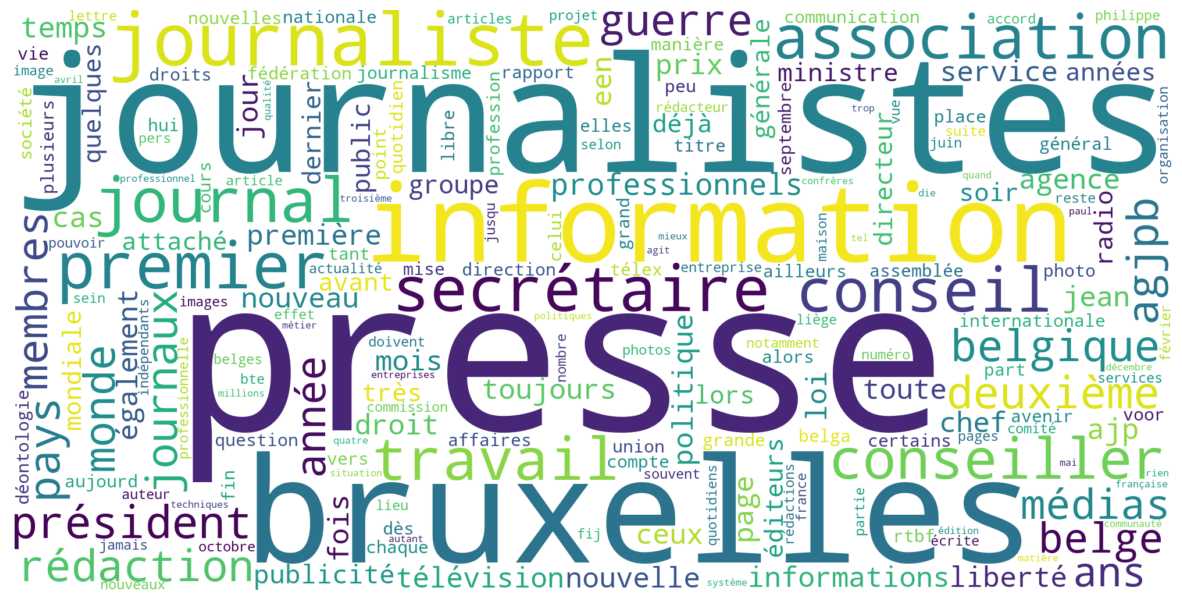

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(width=2000, height=1000, background_color="white").generate_from_frequencies(freq_clean)

plt.figure(figsize=(15, 8))
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("wordcloud_2gm.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
lengths = [len((DATA_DIR / f).read_text(encoding="utf-8", errors="replace")) for f in files]
print("Longueur moyenne :", sum(lengths) / len(lengths))
print("Longueur médiane :", sorted(lengths)[len(lengths)//2])
print("Min / Max :", min(lengths), "/", max(lengths))

Longueur moyenne : 3953.2606060606063
Longueur médiane : 3543
Min / Max : 456 / 13519


In [8]:
import re
from collections import defaultdict, Counter
import spacy

nlp = spacy.load("fr_core_news_sm")

ent_counts = defaultdict(Counter)                      # label -> Counter(forme canonique en minuscule)
ent_display = defaultdict(lambda: defaultdict(Counter)) # label -> canonique -> Counter(formes brutes rencontrées)

for f in files:
    text = re.sub(r"\s+", " ", (DATA_DIR / f).read_text(encoding="utf-8", errors="replace"))
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in {"PER", "ORG", "LOC"} and len(ent.text) > 2:
            raw = ent.text.strip()
            canon = raw.lower()
            ent_counts[ent.label_][canon] += 1
            ent_display[ent.label_][canon][raw] += 1

for label in ("PER", "ORG", "LOC"):
    print(f"\nTop 10 {label} :")
    for canon, c in ent_counts[label].most_common(10):
        best_form = ent_display[label][canon].most_common(1)[0][0]
        print(f"  {best_form} — {c}")


Top 10 PER :
  Presse — 103
  Premier Secrétaire — 88
  Philippe Leruth — 55
  Antwerpen — 52
  Attaché de Presse — 40
  Tervueren — 40
  Martine Simonis — 38
  Charlemagne — 35
  Fax — 34
  Attaché Culturel — 34

Top 10 ORG :
  AGJPB — 392
  RTBF — 198
  Conseil — 139
  FIJ — 135
  Agence Belga — 98
  Fédération Internationale des Journalistes — 52
  IPC — 48
  SAJ — 46
  RSF — 45
  Infos — 40

Top 10 LOC :
  Bruxelles — 1818
  Tél — 1025
  Belgique — 219
  France — 89
  Liège — 88
  Etat — 82
  Paris — 67
  Brussel — 67
  Belga — 62
  Etats-Unis — 60


In [9]:
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer

tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

def sentiment_doc(text, n_chars=2000):
    blob = tb(text[:n_chars])
    return blob.sentiment  # (polarité, subjectivité)

sample_file = files[0]
text_sample = (DATA_DIR / sample_file).read_text(encoding="utf-8", errors="replace")
pol, subj = sentiment_doc(text_sample)

print("Fichier :", sample_file)
print(f"Polarité : {pol:.2f} / Subjectivité : {subj:.2f}")

Fichier : AJP_1980_janvier_1-fr_0005.txt
Polarité : 0.11 / Subjectivité : 0.25


In [10]:
import re

records = []
for fname in files:
    text = (DATA_DIR / fname).read_text(encoding="utf-8", errors="replace")
    pol, subj = sentiment_doc(text)
    year_match = re.search(r"(19|20)\d{2}", fname)
    year = int(year_match.group()) if year_match else None
    records.append({"file": fname, "year": year, "polarity": pol, "subjectivity": subj})

print("Nombre de documents analysés :", len(records))
print("Exemple :", records[0])
print("Exemple :", records[-1])

Nombre de documents analysés : 825
Exemple : {'file': 'AJP_1980_janvier_1-fr_0005.txt', 'year': 1980, 'polarity': 0.10708333333333335, 'subjectivity': 0.24625}
Exemple : {'file': '_README.txt', 'year': None, 'polarity': 0.1762962962962963, 'subjectivity': 0.22703703703703704}


In [11]:
non_articles = [f for f in files if not re.search(r"(19|20)\d{2}", f)]
print("Fichiers non-articles détectés :", non_articles)

files = [f for f in files if f not in non_articles]
records = [r for r in records if r["file"] not in non_articles]

print("Nombre de fichiers après nettoyage :", len(files))
print("Nombre de records après nettoyage :", len(records))

Fichiers non-articles détectés : ['_README.txt']
Nombre de fichiers après nettoyage : 824
Nombre de records après nettoyage : 824


In [12]:
import statistics as stats

pols = [r["polarity"] for r in records]
subjs = [r["subjectivity"] for r in records]

print(f"Polarité moyenne : {stats.mean(pols):.3f} (médiane : {stats.median(pols):.3f})")
print(f"Subjectivité moyenne : {stats.mean(subjs):.3f} (médiane : {stats.median(subjs):.3f})")

by_year = {}
for r in records:
    by_year.setdefault(r["year"], []).append(r["polarity"])

print("\nPolarité moyenne par année :")
for year in sorted(by_year):
    vals = by_year[year]
    print(f"  {year} ({len(vals)} docs) : {stats.mean(vals):.3f}")

Polarité moyenne : 0.105 (médiane : 0.104)
Subjectivité moyenne : 0.185 (médiane : 0.181)

Polarité moyenne par année :
  1980 (52 docs) : 0.122
  1981 (48 docs) : 0.110
  1982 (61 docs) : 0.115
  1983 (42 docs) : 0.099
  1984 (31 docs) : 0.108
  1985 (33 docs) : 0.098
  1986 (22 docs) : 0.094
  1987 (46 docs) : 0.108
  1988 (40 docs) : 0.128
  1989 (34 docs) : 0.125
  1990 (24 docs) : 0.115
  1991 (42 docs) : 0.109
  1992 (23 docs) : 0.088
  1993 (27 docs) : 0.084
  1994 (13 docs) : 0.097
  1995 (25 docs) : 0.095
  1996 (25 docs) : 0.114
  1997 (33 docs) : 0.089
  1998 (31 docs) : 0.112
  1999 (14 docs) : 0.088
  2000 (23 docs) : 0.095
  2001 (47 docs) : 0.099
  2002 (26 docs) : 0.083
  2003 (37 docs) : 0.103
  2004 (25 docs) : 0.091


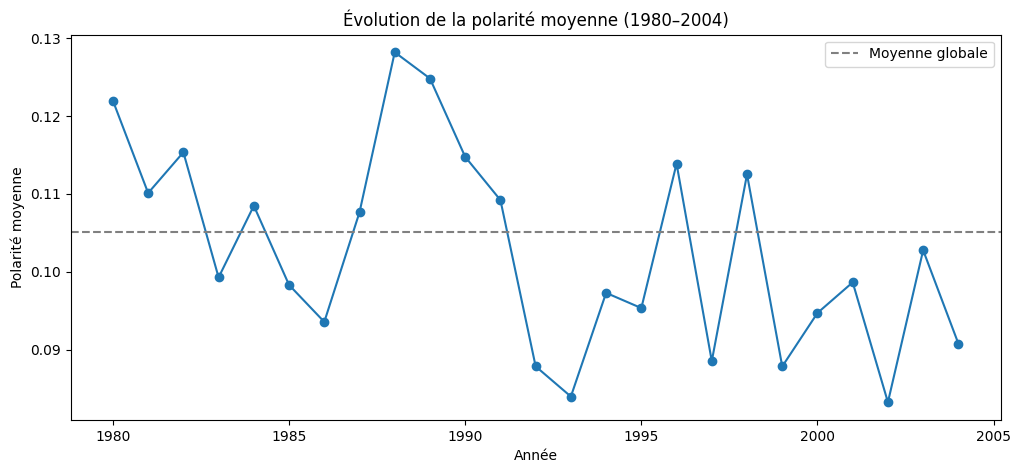

In [13]:
import matplotlib.pyplot as plt

years_sorted = sorted(by_year.keys())
means_sorted = [stats.mean(by_year[y]) for y in years_sorted]

plt.figure(figsize=(12, 5))
plt.plot(years_sorted, means_sorted, marker="o")
plt.axhline(stats.mean(pols), color="gray", linestyle="--", label="Moyenne globale")
plt.xlabel("Année")
plt.ylabel("Polarité moyenne")
plt.title("Évolution de la polarité moyenne (1980–2004)")
plt.legend()
plt.savefig("polarite_par_annee.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

texts = [(DATA_DIR / f).read_text(encoding="utf-8", errors="replace") for f in files]

vectorizer = TfidfVectorizer(
    tokenizer=tokenize,
    stop_words=list(sw),
    max_df=0.6,
    min_df=0.02,
    lowercase=False,   # déjà géré dans tokenize()
)
tfidf_vectors = vectorizer.fit_transform(texts)
print("Dimensions de la matrice TF-IDF :", tfidf_vectors.shape)

Dimensions de la matrice TF-IDF : (824, 2289)


/Users/iduoliveira/TACTEST/tac/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [15]:
N_CLUSTERS = 5
km_model = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = km_model.fit_predict(tfidf_vectors)

from collections import Counter as C
print("Répartition des documents par cluster :", C(clusters))

Répartition des documents par cluster : Counter({1: 383, 0: 226, 2: 99, 3: 67, 4: 49})


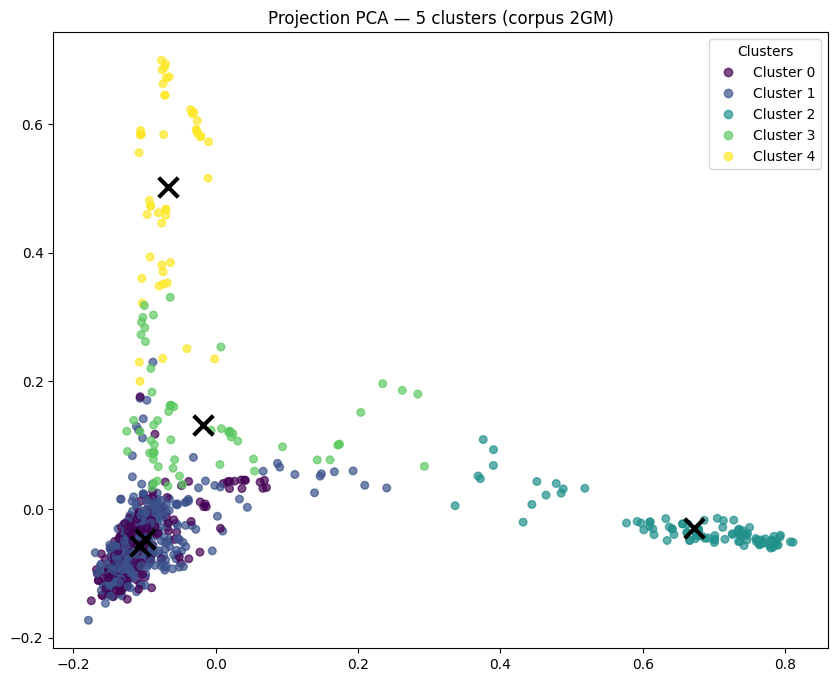

In [16]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_vectors.toarray())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap="viridis", s=30, alpha=0.7)

centroids = pca.transform(km_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=200, linewidths=3, color="black")

plt.legend(handles=scatter.legend_elements()[0], labels=[f"Cluster {i}" for i in range(N_CLUSTERS)], title="Clusters")
plt.title(f"Projection PCA — {N_CLUSTERS} clusters (corpus 2GM)")
plt.savefig("clusters_2gm.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

for c in range(N_CLUSTERS):
    idx = np.where(clusters == c)[0]
    mean_tfidf = tfidf_vectors[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:12]
    top_words = feature_names[top_idx]
    print(f"Cluster {c} ({len(idx)} docs) : {', '.join(top_words)}")

Cluster 0 (226 docs) : page, journal, journaliste, information, guerre, journaux, toujours, quotidien, monde, temps, jour, mois
Cluster 1 (383 docs) : conseil, journaliste, agjpb, bruxelles, information, association, travail, agence, ajp, prix, membres, médias
Cluster 2 (99 docs) : bruxelles, conseiller, secrétaire, télex, attaché, premier, roosevelt, culturel, bte, louise, affaires, mme
Cluster 3 (67 docs) : périodique, siemens, association, président, annonceurs, bruxelles, president, fédération, belgique, mondiale, desguin, général
Cluster 4 (49 docs) : een, voor, pers, die, dat, door, belgische, over, journalisten, met, als, bij


In [18]:
import re
from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

def split_sentences(text):
    # découpage simple sur les ponctuations fortes
    text = re.sub(r"\s+", " ", text)
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 10]

def tokenize_sentence(sentence):
    return tokenize(sentence)  # on réutilise la fonction du bloc 2

all_sentences = []
for f in files:
    text = (DATA_DIR / f).read_text(encoding="utf-8", errors="replace")
    for sent in split_sentences(text):
        tokens = tokenize_sentence(sent)
        if len(tokens) >= 3:
            all_sentences.append(tokens)

print("Nombre de phrases obtenues :", len(all_sentences))
print("Exemple de phrase tokenisée :", all_sentences[0])

Nombre de phrases obtenues : 22483
Exemple de phrase tokenisée : ['est', 'toujours', 'utile', 'côtoyer', 'confrère', 'étranger', 'que', 'soit', 'dans', 'les', 'couloirs', 'berlaymont', 'bar']


In [19]:
bigram_phrases = Phrases(all_sentences, min_count=5, threshold=10)
bigram_phraser = Phraser(bigram_phrases)

trigram_phrases = Phrases(bigram_phraser[all_sentences], min_count=5, threshold=10)
trigram_phraser = Phraser(trigram_phrases)

corpus = list(trigram_phraser[bigram_phraser[all_sentences]])

print("Exemple de phrase avec bigrammes/trigrammes :", corpus[0])

Exemple de phrase avec bigrammes/trigrammes : ['est', 'toujours', 'utile', 'côtoyer', 'confrère', 'étranger', 'que', 'soit', 'dans', 'les', 'couloirs', 'berlaymont', 'bar']


In [20]:
merged_examples = [s for s in corpus if any("_" in tok for tok in s)]
print("Nombre de phrases contenant au moins un bigramme/trigramme :", len(merged_examples))
print("Exemples :")
for s in merged_examples[:5]:
    print(" ", s)

Nombre de phrases contenant au moins un bigramme/trigramme : 15905
Exemples :
  ['dans', 'les', 'colonnes', 'bulletin', 'que_nous_avons', 'décidé', 'leur', 'ouvrir', 'réguliérement']
  ['verra', 'lecture', 'texte', 'que', 'nous', 'donné', 'notre_ami', 'john', 'palmer', 'que', 'cette_décision', 'peut_être', 'prévenu', 'extremis', 'une', 'redoutable', 'explosion']
  ['nous', 'attendons', 'avec', 'curiosité', 'connaître', 'les', 'réactions', 'quelques_uns', 'des', 'destinataires', 'pavé', 'dans', 'mare']
  ['plupart_des', 'journalistes_étrangers', 'basés', 'bruxelles', 'éprou', 'ent', 'des', 'sentiments', 'mitigés', 'quant_aux', 'conditions_travail', 'dans', 'capitale', 'belge']
  ['une_part', 'bruxelles', 'est', 'centre', 'relativement', 'commode', 'pour', 'les', 'communications', 'les', 'déplacements', 'internationaux']


In [21]:
model_a = Word2Vec(corpus, vector_size=100, window=5, min_count=5, workers=4, epochs=10)
model_b = Word2Vec(corpus, vector_size=100, window=10, min_count=3, workers=4, epochs=10)

print("Vocabulaire modèle A :", len(model_a.wv))
print("Vocabulaire modèle B :", len(model_b.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulaire modèle A : 10090
Vocabulaire modèle B : 14800


In [22]:
word_pairs = [
    ("guerre", "occupation"),
    ("journaliste", "presse"),
    ("guerre", "paix"),
]

for model_name, model in [("A", model_a), ("B", model_b)]:
    print(f"\nModèle {model_name} :")
    for w1, w2 in word_pairs:
        if w1 in model.wv and w2 in model.wv:
            score = model.wv.similarity(w1, w2)
            print(f"  similarity({w1!r}, {w2!r}) = {score:.3f}")
        else:
            missing = w1 if w1 not in model.wv else w2
            print(f"  '{missing}' absent du vocabulaire du modèle {model_name}")


Modèle A :
  similarity('guerre', 'occupation') = 0.897
  similarity('journaliste', 'presse') = 0.187
  similarity('guerre', 'paix') = 0.805

Modèle B :
  similarity('guerre', 'occupation') = 0.903
  similarity('journaliste', 'presse') = 0.156
  similarity('guerre', 'paix') = 0.779


In [23]:
target_words = ["guerre", "résistance", "occupation"]

for model_name, model in [("A", model_a), ("B", model_b)]:
    print(f"\nModèle {model_name} :")
    for w in target_words:
        if w in model.wv:
            print(f"  most_similar('{w}') :")
            for sim_word, score in model.wv.most_similar(w, topn=8):
                print(f"    {sim_word} — {score:.3f}")
        else:
            print(f"  '{w}' absent du vocabulaire du modèle {model_name}")


Modèle A :
  most_similar('guerre') :
    cache — 0.946
    posé — 0.946
    lieu — 0.944
    place — 0.943
    vie_privée — 0.943
    étroite — 0.943
    nous_aurons — 0.941
    genres — 0.940
  most_similar('résistance') :
    sauvegarde — 0.997
    pro — 0.996
    ultra — 0.996
    traitement_information — 0.996
    terrain — 0.996
    réussite — 0.996
    bagdad — 0.996
    pour_presse_écrite — 0.995
  most_similar('occupation') :
    extérieur — 0.994
    répond — 0.993
    voit — 0.993
    appel — 0.993
    étant — 0.993
    delà — 0.993
    exprimer — 0.992
    entendu — 0.992

Modèle B :
  most_similar('guerre') :
    genres — 0.971
    lignes — 0.965
    mondes — 0.965
    interviennent — 0.964
    lieu — 0.963
    radios_libres — 0.963
    séquences — 0.961
    diffuser — 0.959
  most_similar('résistance') :
    fer — 0.994
    pré — 0.994
    corporation — 0.994
    pendant_guerre — 0.994
    fiscale — 0.994
    tennis — 0.994
    contact — 0.993
    fondation — 0.993
  mos

In [24]:
for model_name, model in [("A", model_a), ("B", model_b)]:
    print(f"\nModèle {model_name} :")
    for w in ["guerre", "résistance", "occupation", "journaliste", "presse"]:
        if w in model.wv:
            count = model.wv.get_vecattr(w, "count")
            print(f"  '{w}' : vu {count} fois dans le corpus d'entraînement")
        else:
            print(f"  '{w}' absent du vocabulaire")


Modèle A :
  'guerre' : vu 289 fois dans le corpus d'entraînement
  'résistance' : vu 10 fois dans le corpus d'entraînement
  'occupation' : vu 10 fois dans le corpus d'entraînement
  'journaliste' : vu 705 fois dans le corpus d'entraînement
  'presse' : vu 1226 fois dans le corpus d'entraînement

Modèle B :
  'guerre' : vu 289 fois dans le corpus d'entraînement
  'résistance' : vu 10 fois dans le corpus d'entraînement
  'occupation' : vu 10 fois dans le corpus d'entraînement
  'journaliste' : vu 705 fois dans le corpus d'entraînement
  'presse' : vu 1226 fois dans le corpus d'entraînement


In [25]:
target_words = ["guerre", "journaliste", "presse", "bruxelles"]

for model_name, model in [("A", model_a), ("B", model_b)]:
    print(f"\nModèle {model_name} :")
    for w in target_words:
        count = model.wv.get_vecattr(w, "count")
        print(f"  most_similar('{w}', vu {count} fois) :")
        for sim_word, score in model.wv.most_similar(w, topn=8):
            print(f"    {sim_word} — {score:.3f}")


Modèle A :
  most_similar('guerre', vu 289 fois) :
    cache — 0.946
    posé — 0.946
    lieu — 0.944
    place — 0.943
    vie_privée — 0.943
    étroite — 0.943
    nous_aurons — 0.941
    genres — 0.940
  most_similar('journaliste', vu 705 fois) :
    son — 0.961
    premier — 0.928
    fut — 0.911
    était — 0.907
    journal — 0.886
    grand — 0.882
    deuxième — 0.878
    première — 0.878
  most_similar('presse', vu 1226 fois) :
    centre — 0.857
    international — 0.856
    renseignements_administratifs_telemoustique_hebdomadaire — 0.850
    rtbf — 0.815
    publicité — 0.814
    jacques_jordaens — 0.810
    herbes — 0.807
    avenue_des_arts — 0.805
  most_similar('bruxelles', vu 983 fois) :
    rue — 0.953
    beurre — 0.951
    avenue — 0.942
    renard — 0.934
    tél — 0.930
    premier_secrétaire — 0.930
    bte_bruxelles — 0.914
    conseiller — 0.913

Modèle B :
  most_similar('guerre', vu 289 fois) :
    genres — 0.971
    lignes — 0.965
    mondes — 0.965
    in

In [26]:
def tokenize_no_sw(sentence):
    return [t for t in tokenize(sentence) if t not in sw]

corpus_clean = []
for f in files:
    text = (DATA_DIR / f).read_text(encoding="utf-8", errors="replace")
    for sent in split_sentences(text):
        tokens = tokenize_no_sw(sent)
        if len(tokens) >= 3:
            corpus_clean.append(tokens)

bigram_c = Phraser(Phrases(corpus_clean, min_count=5, threshold=10))
corpus_clean_final = list(bigram_c[corpus_clean])

model_c = Word2Vec(corpus_clean_final, vector_size=100, window=5, min_count=5, workers=4, epochs=10)

for w in ["guerre", "journaliste", "presse", "bruxelles"]:
    print(f"\nmost_similar('{w}') :")
    for sim_word, score in model_c.wv.most_similar(w, topn=8):
        print(f"  {sim_word} — {score:.3f}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



most_similar('guerre') :
  peu — 0.994
  toujours — 0.993
  souvent — 0.993
  question — 0.993
  certains — 0.993
  ceux — 0.992
  très — 0.992
  reste — 0.991

most_similar('journaliste') :
  journal — 0.978
  quotidien — 0.974
  celui — 0.972
  cas — 0.971
  jour — 0.970
  premier — 0.969
  article — 0.969
  grand — 0.968

most_similar('presse') :
  service — 0.925
  sorti_simple — 0.907
  information — 0.900
  agence_télégraphique — 0.894
  agence — 0.892
  document_base — 0.884
  cger_disposition — 0.882
  verduyn_ludwig — 0.878

most_similar('bruxelles') :
  conseiller — 0.832
  premier_secrétaire — 0.785
  aurel — 0.753
  marie_bourgogne — 0.741
  attaché_presse — 0.733
  louise_bte — 0.724
  mme — 0.723
  fossé_loups — 0.717


In [27]:
composite_terms = ["deuxième_guerre_mondiale", "deuxième_guerre", "guerre_mondiale"]
for term in composite_terms:
    if term in model_c.wv:
        count = model_c.wv.get_vecattr(term, "count")
        print(f"'{term}' trouvé, vu {count} fois")
        for sim_word, score in model_c.wv.most_similar(term, topn=8):
            print(f"    {sim_word} — {score:.3f}")
    else:
        print(f"'{term}' absent du vocabulaire (pas fusionné ou trop rare)")

'deuxième_guerre_mondiale' absent du vocabulaire (pas fusionné ou trop rare)
'deuxième_guerre' absent du vocabulaire (pas fusionné ou trop rare)
'guerre_mondiale' trouvé, vu 17 fois
    plainte — 0.998
    période — 0.998
    dernière — 0.998
    écrit — 0.998
    date — 0.998
    choisi — 0.998
    partir — 0.997
    livre — 0.997
